In [1]:
# =========================
# 1. IMPORTS & CONFIG
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report

# Paths & settings
#DATA_DIR = "/kaggle/input/face-recognition-dataset/Original Images/Original Images"
DATA_DIR = "../input/face-recognition-dataset-4/face-recognition-dataset-4/Original Images/Original Images/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Preprocessing settings
TO_GRAY = False
NORMALIZE_MODE = 'per_image'   # 'per_image' | 'minmax' | 'dataset'
STATS_DIR = "./stats"; os.makedirs(STATS_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

2025-08-14 11:28:48.308502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755170928.547644      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755170928.613358      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# =========================
# 2. PREPROCESSING FUNCTIONS
# =========================
def _maybe_gray(img):
    return tf.image.rgb_to_grayscale(img) if TO_GRAY else img

def _local_contrast(img):
    return tf.image.adjust_contrast(img, 1.5)

def _per_image_standardize(img):
    return tf.image.per_image_standardization(img)

def _minmax(img):
    mn = tf.reduce_min(img); mx = tf.reduce_max(img)
    return tf.where(tf.equal(mx, mn), img - mn, (img - mn) / (mx - mn + 1e-8))

def _apply_norm(img):
    mode = NORMALIZE_MODE.lower()
    if mode == 'per_image':
        return tf.image.per_image_standardization(img)
    if mode == 'minmax':
        mn = tf.reduce_min(img); mx = tf.reduce_max(img)
        return tf.where(tf.equal(mx, mn), img - mn, (img - mn)/(mx - mn + 1e-8))
    if mode == 'dataset':
        # Ensure inputs are on the SAME scale used to compute stats (we used [0,1])
       # img = img / 255.0
        img = tf.cast(img, tf.float32) / 255.0  # same scale used in stats

        mean = np.load(os.path.join(STATS_DIR, "mean.npy"))
        std  = np.load(os.path.join(STATS_DIR, "std.npy"))
        mean = tf.convert_to_tensor(mean, tf.float32)
        std  = tf.convert_to_tensor(std,  tf.float32)
        return (img - mean) / (std + 1e-6)
    return img / 255.0
    
def preprocess_tensor(img, augment=False):
    img = tf.cast(img, tf.float32)
    img = _maybe_gray(img)
    img = _local_contrast(img)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.05)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    return img


In [3]:
# =========================
# 3. HISTOGRAM & VISUALIZATION
# =========================
def plot_image(arr, title="Image"):
    if arr.ndim == 2:
        plt.figure(); plt.imshow(arr, cmap="gray"); plt.title(title); plt.axis("off"); plt.show()
    else:
        vmin, vmax = np.percentile(arr, 1), np.percentile(arr, 99)
        disp = np.clip((arr - vmin) / (vmax - vmin + 1e-8), 0, 1)
        plt.figure(); plt.imshow(disp); plt.title(title); plt.axis("off"); plt.show()

def plot_hist(arr, title="Histogram", bins=256):
    a = arr
    if a.ndim == 3 and a.shape[-1] == 3 and not TO_GRAY:
        a = a.mean(axis=-1)
    plt.figure(); plt.hist(a.flatten(), bins=bins)
    plt.title(title); plt.xlabel("Intensity"); plt.ylabel("Frequency"); plt.grid(True); plt.show()

from tensorflow.keras.preprocessing.image import load_img, img_to_array

def show_before_after(idx=0):
    # Gather all file paths from the dataset directory
    all_paths = []
    for class_name in class_names:
        class_dir = os.path.join(DATA_DIR, class_name)
        for fname in sorted(os.listdir(class_dir)):
            all_paths.append(os.path.join(class_dir, fname))
    
    if idx >= len(all_paths):
        print(f"Index {idx} is out of range (dataset has {len(all_paths)} images).")
        return
    
    fp = all_paths[idx]
    
    # RAW image
    raw_pil = load_img(fp, target_size=IMG_SIZE)
    raw = img_to_array(raw_pil)
    
    # PREPROCESSED + normalized
    prep = _apply_norm(preprocess_tensor(raw))
    
    # Display images
    plot_image(raw.astype(np.uint8), "RAW")
    plot_hist(raw, "RAW histogram")
    plot_image(prep, "After preprocessing + normalization")
    plot_hist(prep.numpy(), "Histogram after preprocessing + normalization")
    
    # Stats
    print("RAW  min/max:", raw.min(), raw.max())
    print("PREP min/max:", prep.numpy().min(), prep.numpy().max())


In [4]:
# =========================
# 4. DATA LOADING & SPLITTING (70/15/15) 
# =========================

# Load raw datasets (NO preprocessing yet)
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.30,  # 30% for val+test
    subset='training'
)

temp_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.30,
    subset='validation'
)

# Save class names before preprocessing so we can use them later
class_names = train_ds_raw.class_names

# Split temp_ds_raw into val (15%) and test (15%)
val_size = int(0.5 * tf.data.experimental.cardinality(temp_ds_raw).numpy())
val_ds_raw = temp_ds_raw.take(val_size)
test_ds_raw = temp_ds_raw.skip(val_size)


Found 2037 files belonging to 23 classes.
Using 1426 files for training.


I0000 00:00:1755170943.697280      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1755170943.697932      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2037 files belonging to 23 classes.
Using 611 files for validation.


In [5]:
# =========================
# 5. Compute dataset mean/std ONCE 
# =========================

def compute_mean_std_from_decoded(ds, max_batches=300):
    n_pix = 0
    s = None; ss = None
    for i, (xb, _) in enumerate(ds):
        # xb is already decoded float/uint8; make it float in [0,1]
        x = tf.cast(xb, tf.float32) / 255.0
        if x.shape.rank == 4 and x.shape[-1] == 1:
            x = tf.repeat(x, repeats=3, axis=-1)  # ensure 3 channels if grayscale

        b, h, w, c = x.shape
        flat = tf.reshape(x, [b*h*w, c])
        sum_ = tf.reduce_sum(flat, axis=0)
        sumsq_ = tf.reduce_sum(tf.square(flat), axis=0)

        s  = sum_ if s is None else s + sum_
        ss = sumsq_ if ss is None else ss + sumsq_
        n_pix += b*h*w

        if max_batches and (i+1) >= max_batches: break

    mean = s / tf.cast(n_pix, tf.float32)
    var  = (ss / tf.cast(n_pix, tf.float32)) - tf.square(mean)
    std  = tf.sqrt(tf.maximum(var, 1e-8))

    np.save(os.path.join(STATS_DIR, "mean.npy"), mean.numpy())
    np.save(os.path.join(STATS_DIR, "std.npy"),  std.numpy())
    print("Saved stats:", mean.numpy(), std.numpy())

# Build a safe stream: decode happens inside image_dataset_from_directory,
# .ignore_errors() will skip any item that fails to decode.
safe_for_stats = train_ds_raw.ignore_errors()

# (Optional) light preprocessing for stats — NO contrast, just cast/scale happens inside the function.
compute_mean_std_from_decoded(safe_for_stats)

Saved stats: [0.63505125 0.47619325 0.39946234] [0.2583456  0.21951634 0.20508978]


In [6]:
# =========================
# 6. APPLY PREPROCESSING TO DATASETS
# =========================

train_ds = train_ds_raw.map(lambda x, y: (_apply_norm(preprocess_tensor(x, augment=True)), y),
                            num_parallel_calls=AUTOTUNE).ignore_errors()
val_ds   = val_ds_raw.map(lambda x, y: (_apply_norm(preprocess_tensor(x, augment=False)), y),
                          num_parallel_calls=AUTOTUNE).ignore_errors()
test_ds  = test_ds_raw.map(lambda x, y: (_apply_norm(preprocess_tensor(x, augment=False)), y),
                           num_parallel_calls=AUTOTUNE).ignore_errors()

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


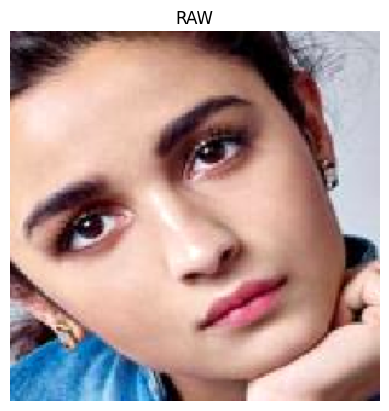

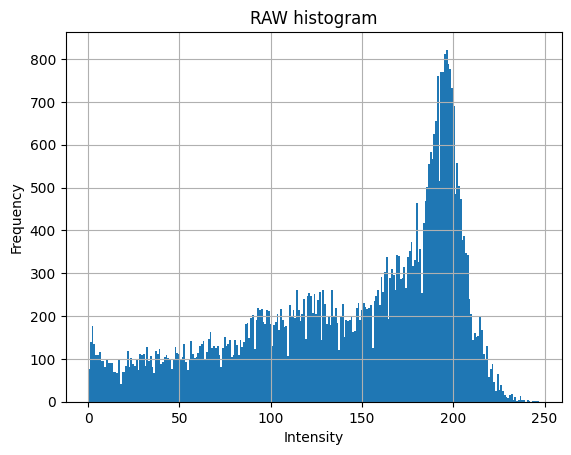

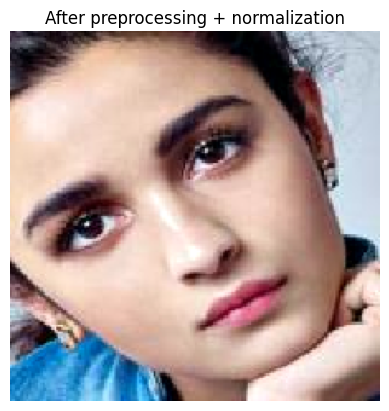

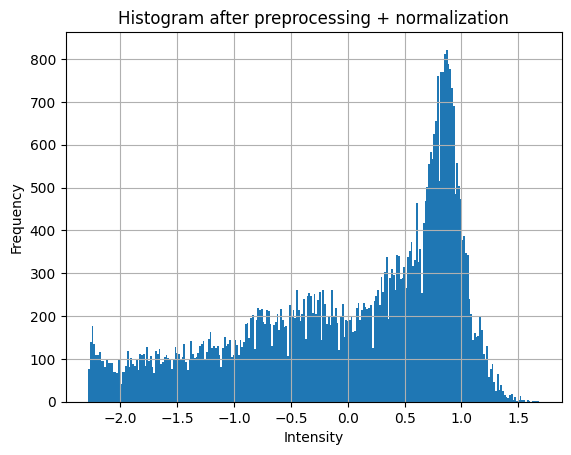

RAW  min/max: 0.0 255.0
PREP min/max: -2.3916965 1.7411746


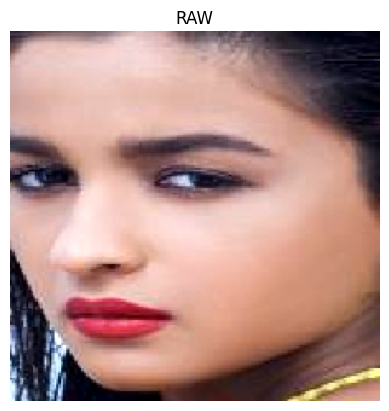

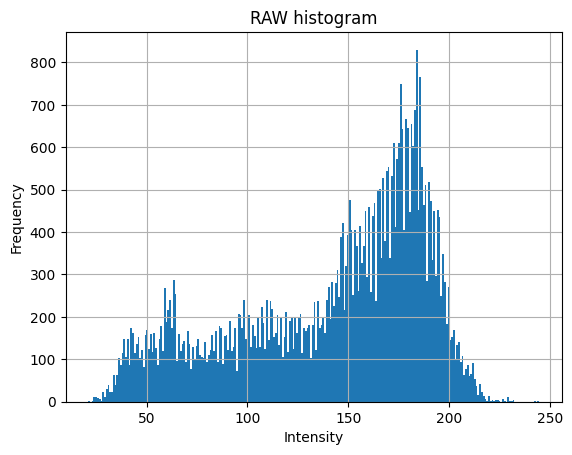

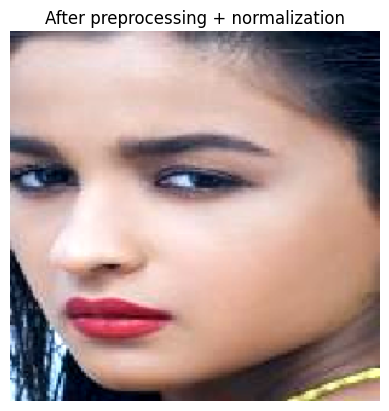

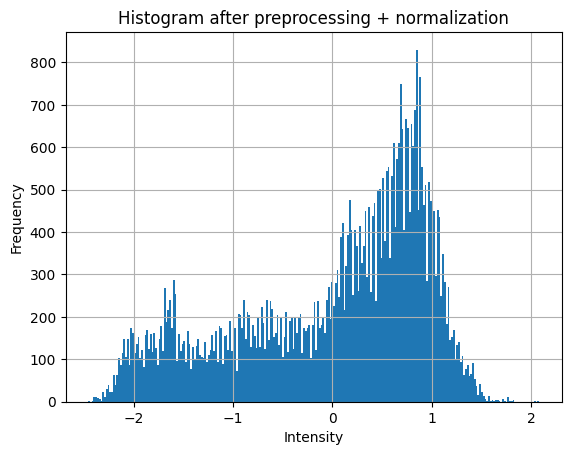

RAW  min/max: 16.0 255.0
PREP min/max: -2.683522 2.3780744


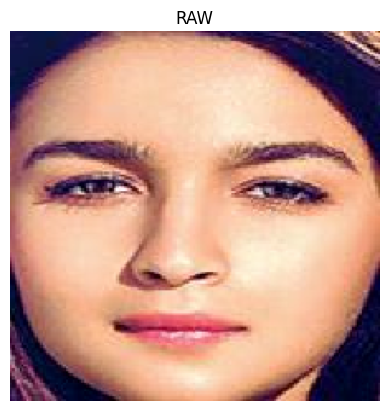

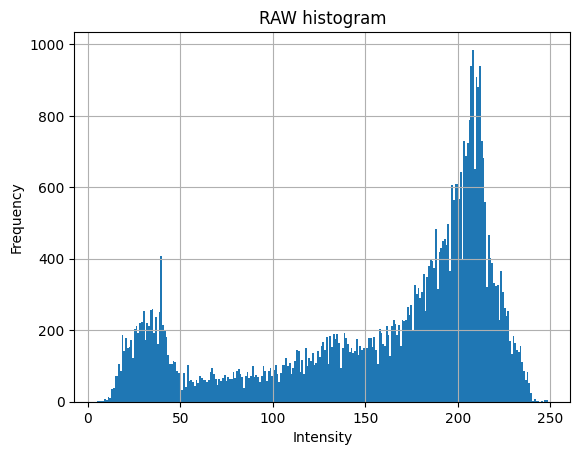

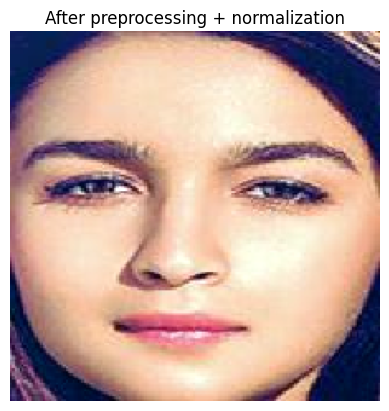

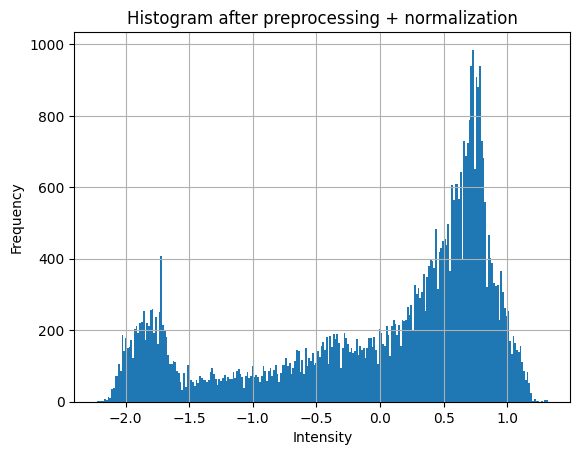

RAW  min/max: 0.0 255.0
PREP min/max: -2.4725204 1.4164228


In [7]:
# =========================
# 7. IMAGE & HISTOGRAM VISUALIZATION  — before vs after preprocessing+normalization
# =========================
show_before_after(0)   # first image
show_before_after(10)  # 11th image
show_before_after(50)  # 51st image

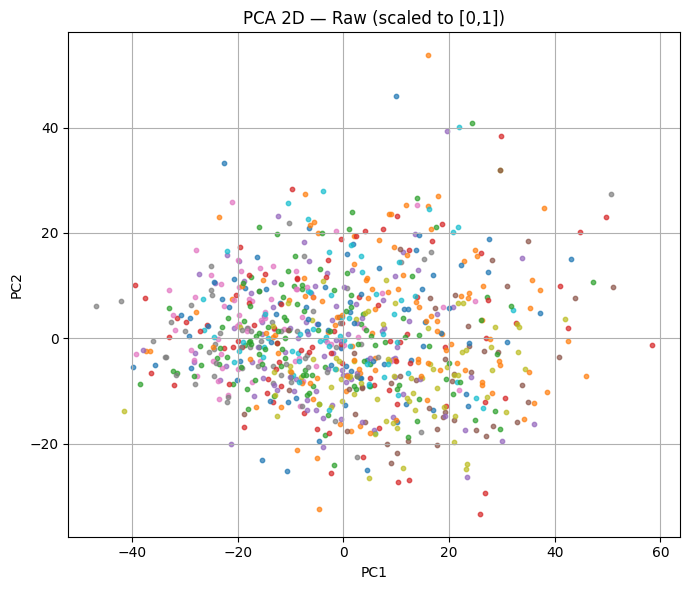

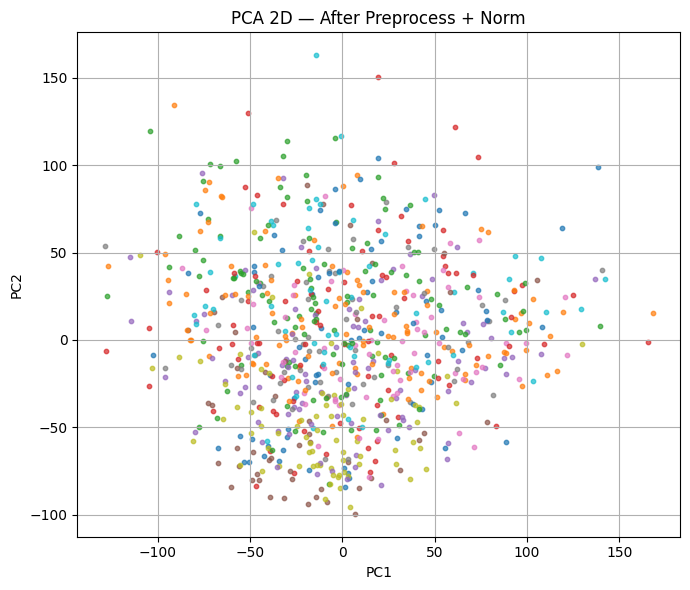

Explained variance (2D) raw:    [0.2153 0.0895]
Explained variance (2D) after:  [0.1053 0.0865]


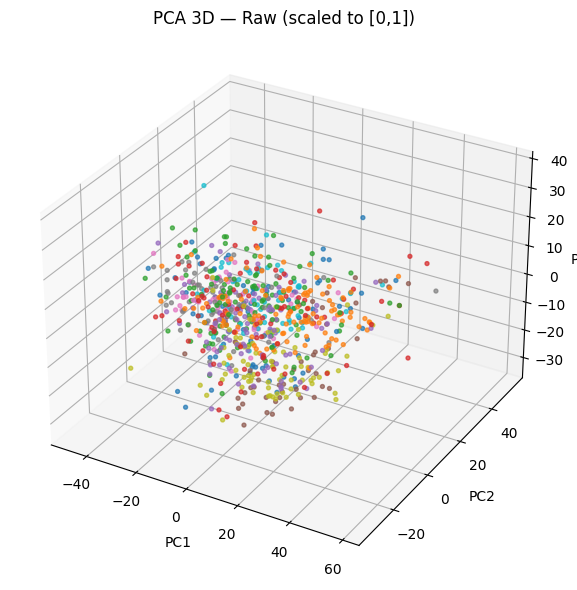

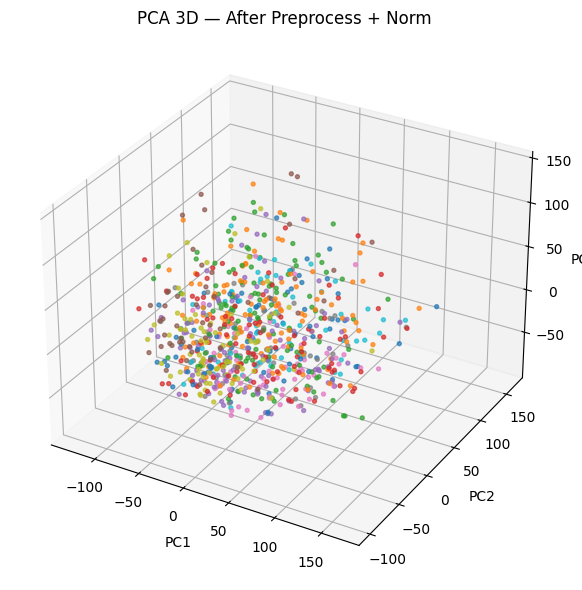

Explained variance (3D) raw:    [0.2153 0.0895 0.0785]
Explained variance (3D) after:  [0.1053 0.0865 0.0688]


In [8]:
# =========================
# 8. PCA VISUALIZATION (2D & 3D) — before vs after preprocessing+normalization
# =========================
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for 3D)

# How many images to sample and the size to downscale to (for speed)
PCA_SAMPLES = 800
PCA_IMG_SIZE = (112, 112)  # can raise to 160 or 224 if you have time

def _collect_raw_and_after(ds_raw, n=PCA_SAMPLES, resize_to=PCA_IMG_SIZE):
    """Collect paired (raw, after preprocess+norm) arrays with labels from a raw dataset."""
    xs_raw, xs_after, ys = [], [], []
    collected = 0

    # Use unbatch() so we can take individual images
    for xb, yb in ds_raw.unbatch():
        # ---- Raw (scaled to [0,1] just for PCA stability)
        x_raw = tf.image.resize(xb, resize_to)
        x_raw = tf.cast(x_raw, tf.float32) / 255.0

        # ---- After (your preprocessing + normalization)
        x_uint = tf.image.resize(xb, resize_to)
        x_uint = tf.cast(x_uint, tf.float32)  # still in 0..255 for your pipeline
        x_after = preprocess_tensor(x_uint, augment=False)
        x_after = _apply_norm(x_after)

        xs_raw.append(x_raw.numpy())
        xs_after.append(x_after.numpy())
        ys.append(int(yb.numpy()))
        collected += 1
        if collected >= n:
            break

    xs_raw = np.stack(xs_raw, axis=0)     # [N,H,W,C]
    xs_after = np.stack(xs_after, axis=0) # [N,H,W,C]
    ys = np.array(ys)
    return xs_raw, xs_after, ys

def _to_vectors(x4d):
    return x4d.reshape(x4d.shape[0], -1)

def _pca_nd(X, n_components=2):
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(X)
    return Z, pca

def _scatter_2d(Z, y, title, class_names, max_legend=12, alpha=0.7, s=10):
    plt.figure(figsize=(7,6))
    classes = np.unique(y)
    show_legend = (len(classes) <= max_legend)
    for cls in classes:
        idx = (y == cls)
        plt.scatter(Z[idx,0], Z[idx,1], s=s, alpha=alpha,
                    label=class_names[cls] if show_legend else None)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    if show_legend:
        plt.legend(markerscale=2, fontsize=8, frameon=False)
    plt.grid(True); plt.tight_layout(); plt.show()

def _scatter_3d(Z, y, title, class_names, max_legend=10, alpha=0.7, s=8):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    classes = np.unique(y)
    show_legend = (len(classes) <= max_legend)
    for cls in classes:
        idx = (y == cls)
        ax.scatter(Z[idx,0], Z[idx,1], Z[idx,2], s=s, alpha=alpha,
                   label=class_names[cls] if show_legend else None)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    if show_legend:
        ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()

# ---- Run the PCA pipeline
xs_raw, xs_after, ys = _collect_raw_and_after(train_ds_raw, n=PCA_SAMPLES, resize_to=PCA_IMG_SIZE)

Xr = _to_vectors(xs_raw)
Xa = _to_vectors(xs_after)

# 2D PCA
Zr2, pca_raw2 = _pca_nd(Xr, n_components=2)
Za2, pca_after2 = _pca_nd(Xa, n_components=2)
_scatter_2d(Zr2, ys, "PCA 2D — Raw (scaled to [0,1])", class_names)
_scatter_2d(Za2, ys, "PCA 2D — After Preprocess + Norm", class_names)
print("Explained variance (2D) raw:   ", np.round(pca_raw2.explained_variance_ratio_, 4))
print("Explained variance (2D) after: ", np.round(pca_after2.explained_variance_ratio_, 4))

# 3D PCA
Zr3, pca_raw3 = _pca_nd(Xr, n_components=3)
Za3, pca_after3 = _pca_nd(Xa, n_components=3)
_scatter_3d(Zr3, ys, "PCA 3D — Raw (scaled to [0,1])", class_names)
_scatter_3d(Za3, ys, "PCA 3D — After Preprocess + Norm", class_names)
print("Explained variance (3D) raw:   ", np.round(pca_raw3.explained_variance_ratio_, 4))
print("Explained variance (3D) after: ", np.round(pca_after3.explained_variance_ratio_, 4))

In [9]:
# =========================
# 9. DATA CHECK
# =========================
for xb, yb in train_ds.take(1):
    print("min/max:", float(tf.reduce_min(xb)), float(tf.reduce_max(xb)))
    print("any NaN?", bool(tf.reduce_any(tf.math.is_nan(xb))))
    

min/max: -3.6059024333953857 2.9830358028411865
any NaN? False


In [10]:
# =========================
# 10. MODEL
# =========================
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=IMG_SIZE + (3,)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,252,503 (84.89 MB)

 Trainable params: 22,251,543 (84.88 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
# =========================
# 11. TRAINING
# =========================
EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20


I0000 00:00:1755170967.558608     104 service.cc:148] XLA service 0x78ad64004150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755170967.559750     104 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1755170967.559771     104 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1755170968.147873     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


      2/Unknown 12s 74ms/step - accuracy: 0.0469 - loss: 4.1967

I0000 00:00:1755170974.645522     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     45/Unknown 19s 162ms/step - accuracy: 0.1901 - loss: 3.4378

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.1923 - loss: 3.4247 - val_accuracy: 0.1156 - val_loss: 2.9691
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7127 - loss: 0.9789 - val_accuracy: 0.1187 - val_loss: 3.2610
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9045 - loss: 0.4457 - val_accuracy: 0.1125 - val_loss: 3.8200
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9780 - loss: 0.1809 - val_accuracy: 0.1344 - val_loss: 3.8429
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9861 - loss: 0.1171 - val_accuracy: 0.1969 - val_loss: 3.2550
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9970 - loss: 0.0626 - val_accuracy: 0.3187 - val_loss: 2.5620
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9921 - loss: 0.0627 - val_accuracy: 0.4187 - val_loss: 1.9813
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9986 - loss: 0.0404 - val_accuracy: 0.5625 - val_loss: 

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.7672 - loss: 0.7896
Test Accuracy: 76.29%


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
                   precision    recall  f1-score   support

       Alia Bhatt       0.58      0.78      0.67         9
 Amitabh Bachchan       0.73      1.00      0.85        11
     Andy Samberg       0.81      0.81      0.81        16
    Billie Eilish       0.83      1.00      0.91        10
        Brad Pitt       0.73      0.67      0.70        12
   Camila Cabello       0.73      0.89      0.80         9
  Charlize Theron       0.70      0.54      0.61        13
      Claire Holt       0.82      0.64      0.72        14
     Courtney Cox       0.87      0.93      0.90        14
   Dwayne Johnson       0.9

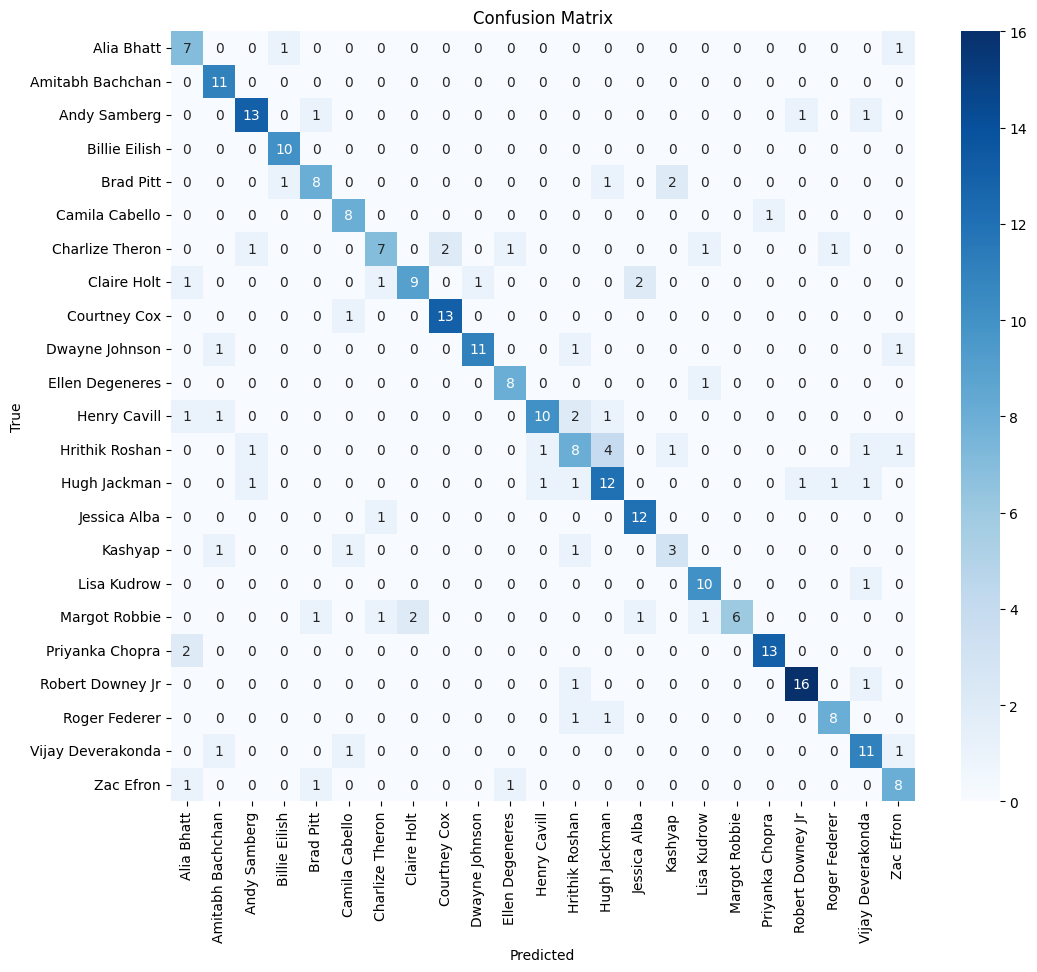

In [12]:
# =========================
# 12. EVALUATION
# =========================
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2%}")

# Collect predictions
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

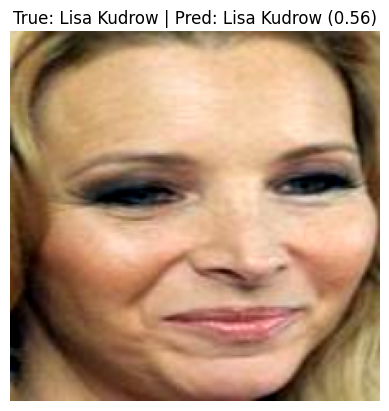

Top-k predictions:
  Lisa Kudrow: 0.556
  Claire Holt: 0.204
  Margot Robbie: 0.092
  Courtney Cox: 0.080
  Charlize Theron: 0.016


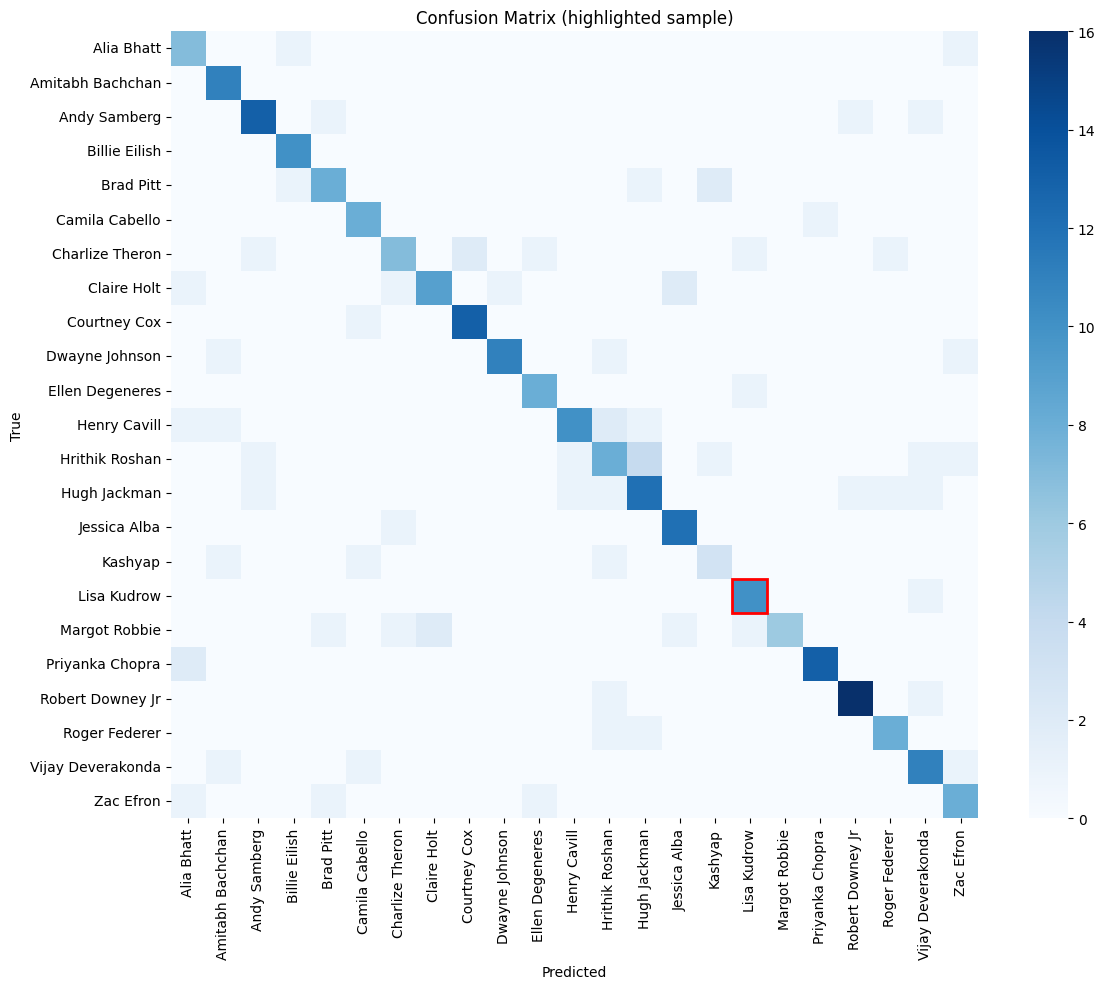

CM cell count for True='Lisa Kudrow', Pred='Lisa Kudrow': 10


In [13]:
# =========================
# 13. RANDOM TEST SAMPLE → PREDICT + HIGHLIGHT IN CONFUSION MATRIX
# =========================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix

def build_confusion_from_ds(ds):
    y_true_local, y_pred_local = [], []
    for xb, yb in ds:
        pb = model.predict(xb, verbose=0)
        y_true_local.extend(yb.numpy())
        y_pred_local.extend(np.argmax(pb, axis=1))
    return np.array(y_true_local), np.array(y_pred_local), confusion_matrix(y_true_local, y_pred_local)

def show_random_test_prediction_and_cm(ds=test_ds, topk=5):
    """
    Picks a random item from `ds` (default: test_ds), predicts with the current model,
    shows the image + top-k, and highlights the (true, pred) cell in the confusion matrix.
    """
    # 1) Ensure we have y_true, y_pred, cm (reuse from Section 8 if already computed)
    global y_true, y_pred, cm
    need_recompute = False
    if 'y_true' not in globals() or 'y_pred' not in globals():
        need_recompute = True
    if 'cm' not in globals():
        need_recompute = True
    if need_recompute:
        print("Computing predictions on test set to build confusion matrix...")
        y_true, y_pred, cm = build_confusion_from_ds(ds)

    # 2) Draw a random batch, pick a random index
    for xb, yb in ds.shuffle(1024).take(1):
        i = np.random.randint(xb.shape[0])
        x = xb[i]                          # already preprocessed as in training
        true_idx = int(yb[i].numpy())

        # Predict this single sample
        probs = model.predict(np.expand_dims(x, axis=0), verbose=0)[0]
        pred_idx = int(np.argmax(probs))

        # 3) Show the image and top-k
        plot_image(x.numpy(), f"True: {class_names[true_idx]} | Pred: {class_names[pred_idx]} ({probs[pred_idx]:.2f})")

        topk = min(topk, len(class_names))
        order = np.argsort(probs)[-topk:][::-1]
        print("Top-k predictions:")
        for j in order:
            print(f"  {class_names[j]}: {probs[j]:.3f}")

        # 4) Plot confusion matrix with the (true,pred) cell highlighted
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(cm, annot=False, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title("Confusion Matrix (highlighted sample)")
        # highlight rectangle at (row=true_idx, col=pred_idx)
        rect = patches.Rectangle((pred_idx, true_idx), 1, 1, fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        plt.tight_layout(); plt.show()

        # Print the count at that cell for validation
        print(f"CM cell count for True='{class_names[true_idx]}', Pred='{class_names[pred_idx]}': {cm[true_idx, pred_idx]}")
        break  # only one random sample per call

# Run it (re-run to sample another image)
show_random_test_prediction_and_cm()

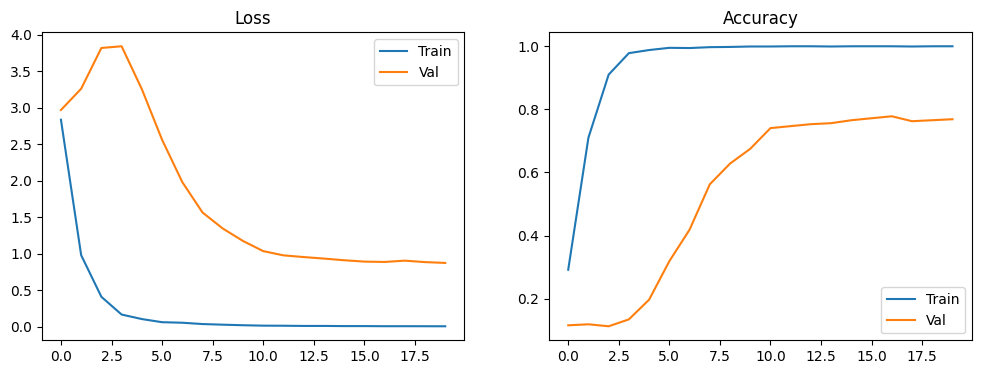

In [14]:
# =========================
# 14. PLOTS
# =========================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title("Accuracy")
plt.show()